In [1]:
%cd ../../

/home/hoanghu/projects/fw-models


In [18]:
from itertools import product

import numpy as np
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import TargetEncoder, OrdinalEncoder
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
# import lightning as L
# import torch.nn.functional as F
# from torch import nn
# from torch.optim import AdamW
# from torch.utils.data import Dataset, DataLoader
# import torch
# from torch.nn import Module
# from torch import Tensor
# from torchmetrics.regression import MeanSquaredError, R2Score
# from lightning.pytorch.callbacks import RichProgressBar
# from lightning.pytorch.loggers import TensorBoardLogger
# from sklearn.preprocessing import MinMaxScaler
from polars import DataFrame

In [19]:
plt.style.use('seaborn-v0_8')
plt.rcParams.update({'font.size': 8})

# Load data and resources

In [3]:
path = "data/processed/phase_4/dim_pieces_per_dish.xlsx"

pos = pl.read_excel(path)
pos.head()

date,restaurant,meal_type,pcs,meal_id
date,str,str,i64,i64
2023-01-02,"""che""","""fish""",78,9500055
2023-01-02,"""che""","""vegan""",84,6128
2023-01-02,"""che""","""meat""",165,9500160
2023-01-03,"""che""","""vegetarian""",29,1270
2023-01-03,"""che""","""fish""",105,6156


In [4]:
path = "data/inter/meal_names_embds.parquet"
meal_names_embd = pl.read_parquet(path)

meal_names_embd.head()

meal_id,meal,embedding,__index_level_0__
i64,str,list[f64],i64
7010,"""Aurajuusto-pinaattilasagnette""","[0.011678, -0.039025, … 0.035513]",4
7010,"""Aurajuusto-pinaattilasagnettea""","[0.01346, -0.047018, … 0.038673]",5
1751,"""BBQ-broilerikastiketta""","[0.050395, 0.037269, … 0.025638]",9
1751,"""BBQ-Broilerikastiketta""","[0.065942, 0.037054, … 0.022381]",10
200006,"""Bar Myöhä Bbq-seitanbowl""","[0.020469, 0.026279, … 0.028041]",13


In [5]:
path = "data/processed/phase_4/dim_meals.xlsx"

dim_meals = pl.read_excel(path)
dim_meals.head()

meal_id,meal_type_1,schoolyear,is_kela,is_new,restaurant,meal_type_2,pcs_mean
i64,str,str,bool,bool,str,str,f64
9017,"""vegan""","""24-25""",true,true,"""che-exa-vik""","""vegan-miscellaneous""",116.3425
7201,"""vegan""","""23-24""",false,false,null,null,106.231119
9032,"""vegan""","""23-24""",false,false,null,null,106.231119
9102,"""vegan""","""23-24""",false,false,null,null,106.231119
7010,"""vegetarian""","""24-25""",false,false,"""che-exa-vik""",null,71.0


## Process dim tables

### dim: `meal_names`

In [6]:
# Keep one entry for each `meal_id`
meal_names_embd = (
    meal_names_embd
    .drop('__index_level_0__')
    .group_by('meal_id')
    .first()
)


# Apply TruncateSVD to reduce embedding size
features = meal_names_embd.select(pl.col("embedding").list.to_struct()).unnest("embedding")
features_truncated = TruncatedSVD(n_components=5).fit_transform(features)
meal_names_embd = (
    meal_names_embd
    .with_columns(pl.Series('embedding', values=features_truncated))
)


meal_names_embd.head()

meal_id,meal,embedding
i64,str,"array[f64, 5]"
5081,"""Kassler, Teriyaki-paahdettua""","[0.701381, 0.077427, … -0.063828]"
1151,"""Vuohenjuusto-tomaattikeitto""","[0.705746, -0.368078, … 0.147296]"
2598,"""Siemenleivitettyä seifileetä""","[0.760899, -0.042632, … 0.244428]"
1021,"""Tofua maapähkinäkastikkeessa""","[0.759901, -0.175956, … -0.012041]"
9500152,"""Tomaat tuorejuusto-tonnikalaka""","[0.686986, -0.271186, … 0.166217]"


### dim: `pos`

In [7]:
# Filter out too low POS values
THETA = 5
pos = pos.filter(pl.col('pcs') >= THETA)

# Keep THETA most consumed meals per date-restaurant
THETA = 4
pos = (
    pos
    .with_columns(
        (pl.col('pcs') + pl.lit(np.random.rand(pos.height))).alias('pcs_rank')
    )
    .with_columns(
        pl.col('pcs_rank').rank(descending=True, method='dense').over("date", 'restaurant').alias('rank')
    )
    .filter(pl.col("rank") <= THETA)
    .drop('rank', 'pcs_rank')
)


pos.head()

date,restaurant,meal_type,pcs,meal_id
date,str,str,i64,i64
2023-01-02,"""che""","""fish""",78,9500055
2023-01-02,"""che""","""vegan""",84,6128
2023-01-02,"""che""","""meat""",165,9500160
2023-01-03,"""che""","""vegetarian""",29,1270
2023-01-03,"""che""","""fish""",105,6156


In [8]:
dim_meals = (
    dim_meals
    .filter(pl.col('restaurant').is_not_null())
    .select(
        'meal_id',
        pl.col('meal_type_1').alias('meal_type'),
        # pl.col('restaurant').str.split('-')
    )
)


dim_meals.head()

meal_id,meal_type
i64,str
9017,"""vegan"""
7010,"""vegetarian"""
6557,"""vegan"""
1751,"""chicken"""
9039,"""vegan"""


# Craft feature

Idea: Refer every meals to `K` highest sale meals per restaurant - meal-type

## Permute the meals per day to augment data rows

In [9]:
list_df = []

pos_aug = (
    pos
    .group_by('date', 'restaurant')
    .agg(pl.concat_list('meal_id').flatten())
)
for _ in range(100):
    df = (
        pos_aug
        .select(
            'date', 'restaurant',
            pl.col('meal_id').list.sample(fraction=1, shuffle=True)
        )
        .with_columns(
            # pl.col('meal_id').list.to_struct(
            #     n_field_strategy="max_width",
            #     fields=lambda idx: f"meal_{idx}"
            # ),
            pl.col('meal_id').cast(pl.List(pl.String)).list.join('-').alias('signature')
        )
    )
    list_df.append(df)
df = pl.concat(list_df)



df.head()

date,restaurant,meal_id,signature
date,str,list[i64],str
2023-10-13,"""vik""","[9500058, 9500161]","""9500058-9500161"""
2024-08-05,"""che""","[7582, 9500064]","""7582-9500064"""
2024-06-27,"""che""","[7575, 1237, 7610]","""7575-1237-7610"""
2023-04-05,"""vik""","[9500027, 1009, … 1011]","""9500027-1009-983-1011"""
2023-05-04,"""che""","[9500076, 9500046, 9500098]","""9500076-9500046-9500098"""


In [10]:
pos_final = (
    df
    .group_by('date', 'restaurant', 'signature')
    .first()
    # .unnest('meal_id')
    .drop('signature')
    .with_row_index()
    .explode('meal_id')
    .join(meal_names_embd.drop('meal'), on='meal_id', how='left')
    .join(dim_meals, on='meal_id', how='left')
    .with_columns(
        pl.col('index').rank(method='ordinal').over('index').alias('meal_rank')
    )
    # .drop('meal_id')
)

# Encode restaurant
enc_restaurant = OrdinalEncoder()
enc_restaurant.fit(pos_final.select('restaurant'))
pos_final = pos_final.with_columns(
    pl.Series('restaurant_enc', values=enc_restaurant.transform(pos_final.select('restaurant'))).arr.first().cast(pl.Int32) + 1,
)



# Encode meal type
enc_meal_type = OrdinalEncoder()
enc_meal_type.fit(pos_final.select('meal_type'))
pos_final = pos_final.with_columns(
    pl.Series('meal_type_enc', values=enc_meal_type.transform(pos_final.select('meal_type'))).arr.first().cast(pl.Int32) + 1,
)



pos_final = (
    pos_final
    .pivot(on='meal_rank', index=['index', 'date', 'restaurant'], values=['embedding', 'meal_id', 'restaurant_enc', 'meal_type_enc'])
    .join(pos.drop('meal_type'), left_on=['date', 'restaurant', 'meal_id_1'], right_on=['date', 'restaurant', 'meal_id'])
    .drop('meal_id_1', 'meal_id_2', 'meal_id_3', 'meal_id_4')
)


# Encode datetime
pos_final = (
    pos_final
    .with_columns(
        pl.col('date').dt.weekday().alias('weekday'),
        pl.col('date').dt.day().alias('day'),
        pl.col('date').dt.month().alias('month'),
    )
    .with_columns(
        (pl.col('weekday') * 2 * np.pi / 7).sin().alias('weekday_sin'),
        (pl.col('weekday') * 2 * np.pi / 7).cos().alias('weekday_cos'),
        (pl.col('day') * 2 * np.pi / 31).sin().alias('day_sin'),
        (pl.col('day') * 2 * np.pi / 31).cos().alias('day_cos'),
        (pl.col('month') * 2 * np.pi / 12).sin().alias('month_sin'),
        (pl.col('month') * 2 * np.pi / 12).cos().alias('month_cos'),
    )
    .drop('weekday', 'day', 'month')
)



# Fill null
lit_embd_null = pl.lit([0., 0., 0., 0., 0.], dtype=pl.List)
lit_restaurant_null = lit_meal_type_null = 0

pos_final = (
    pos_final
    .select(
        'date', 'restaurant',
        'weekday_sin', 'weekday_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos',
        
        pl.col("^embedding_.*$").fill_null(lit_embd_null),
        pl.col("^restaurant_enc_.*$").fill_null(lit_restaurant_null),
        pl.col("^meal_type_enc_.*$").fill_null(lit_meal_type_null),

        'pcs',
    )
)


# Flatten embedding vectors
pos_final = (
    pos_final
    .with_columns(
        pl.col("embedding_1").list.to_struct(n_field_strategy="max_width", fields=lambda idx: f"embd1_{idx}"),
        pl.col("embedding_2").list.to_struct(n_field_strategy="max_width", fields=lambda idx: f"embd2_{idx}"),
        pl.col("embedding_3").list.to_struct(n_field_strategy="max_width", fields=lambda idx: f"embd3_{idx}"),
        pl.col("embedding_4").list.to_struct(n_field_strategy="max_width", fields=lambda idx: f"embd4_{idx}"),
    )
    .unnest('embedding_1', 'embedding_2', 'embedding_3', 'embedding_4')
)


pos_final.head()

date,restaurant,weekday_sin,weekday_cos,day_sin,day_cos,month_sin,month_cos,embd1_0,embd1_1,embd1_2,embd1_3,embd1_4,embd2_0,embd2_1,embd2_2,embd2_3,embd2_4,embd3_0,embd3_1,embd3_2,embd3_3,embd3_4,embd4_0,embd4_1,embd4_2,embd4_3,embd4_4,restaurant_enc_1,restaurant_enc_2,restaurant_enc_3,restaurant_enc_4,meal_type_enc_1,meal_type_enc_2,meal_type_enc_3,meal_type_enc_4,pcs
date,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i32,i32,i32,i32,i32,i32,i32,i32,i64
2023-11-21,"""vik""",0.974928,-0.222521,-0.897805,-0.440394,-0.5,0.866025,0.5666,0.502374,-0.086117,0.019041,0.205252,0.741116,-0.133236,0.212448,0.041688,0.138029,0.666066,-0.175598,-0.04121,0.008159,-0.062783,0.6046,0.027842,-0.32873,0.087805,-0.094665,4,4,4,4,2,2,4,3,144
2024-04-10,"""vik""",0.433884,-0.900969,0.897805,-0.440394,0.866025,-0.5,0.695269,0.335793,0.017363,-0.00951,-0.021744,0.612227,0.261308,0.173802,-0.435744,0.080741,0.716911,-0.237751,-0.203296,-0.024649,0.14935,0.552294,-0.077519,0.038891,0.011233,-0.083601,4,4,4,4,2,4,3,4,116
2023-05-23,"""vik""",0.974928,-0.222521,-0.998717,-0.050649,0.5,-0.866025,0.566102,0.181961,-0.176288,-0.009913,-0.095849,0.731334,-0.01709,0.324718,-0.192376,-0.192034,0.705746,-0.368078,0.100768,-0.084633,0.147296,0.802959,-0.167412,0.043355,0.164251,0.046082,4,4,4,4,4,4,5,1,166
2023-10-19,"""exa""",-0.433884,-0.900969,-0.651372,-0.758758,-0.866025,0.5,0.799069,-0.046036,0.076147,0.283131,0.082783,0.69581,-0.21432,0.035636,-0.083525,0.114771,0.310884,0.278536,-0.251177,-0.028912,0.087004,0.457755,0.179888,-0.298473,-0.029919,-0.234456,2,2,2,2,2,5,4,1,120
2023-04-14,"""exa""",-0.974928,-0.222521,0.299363,-0.954139,0.866025,-0.5,0.809947,-0.206379,0.215837,-0.134769,0.028529,0.750091,0.151063,-0.021067,-0.014195,0.017433,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,2,0,0,4,1,0,0,165


In [16]:
cols_X = [
    pl.col("^embd.*$"),
    pl.col("^restaurant_enc_.*$"),
    pl.col("^meal_type_enc_.*$"),
    'weekday_sin',
    'weekday_cos',
    'day_sin',
    'day_cos',
    'month_sin',
    'month_cos'
]
col_y = 'pcs'
cols_cat = [
    'restaurant_enc_1',
    'restaurant_enc_2',
    'restaurant_enc_3',
    'restaurant_enc_4',
    'meal_type_enc_1',
    'meal_type_enc_2',
    'meal_type_enc_3',
    'meal_type_enc_4',
]


CUTOFF_DATE = pl.lit("2024-10-01", dtype=pl.Date)
pos_train = pos_final.filter(pl.col('date') < CUTOFF_DATE)
pos_val = pos_final.filter(pl.col('date') >= CUTOFF_DATE)

Xtrain, ytrain = pos_train.select(cols_X).to_pandas(), pos_train.get_column(col_y).to_pandas()
Xval, yval = pos_val.select(cols_X).to_pandas(), pos_val.get_column(col_y).to_pandas()

pos_train.head()

date,restaurant,weekday_sin,weekday_cos,day_sin,day_cos,month_sin,month_cos,embd1_0,embd1_1,embd1_2,embd1_3,embd1_4,embd2_0,embd2_1,embd2_2,embd2_3,embd2_4,embd3_0,embd3_1,embd3_2,embd3_3,embd3_4,embd4_0,embd4_1,embd4_2,embd4_3,embd4_4,restaurant_enc_1,restaurant_enc_2,restaurant_enc_3,restaurant_enc_4,meal_type_enc_1,meal_type_enc_2,meal_type_enc_3,meal_type_enc_4,pcs
date,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i32,i32,i32,i32,i32,i32,i32,i32,i64
2023-11-21,"""vik""",0.974928,-0.222521,-0.897805,-0.440394,-0.5,0.866025,0.5666,0.502374,-0.086117,0.019041,0.205252,0.741116,-0.133236,0.212448,0.041688,0.138029,0.666066,-0.175598,-0.04121,0.008159,-0.062783,0.6046,0.027842,-0.32873,0.087805,-0.094665,4,4,4,4,2,2,4,3,144
2024-04-10,"""vik""",0.433884,-0.900969,0.897805,-0.440394,0.866025,-0.5,0.695269,0.335793,0.017363,-0.00951,-0.021744,0.612227,0.261308,0.173802,-0.435744,0.080741,0.716911,-0.237751,-0.203296,-0.024649,0.14935,0.552294,-0.077519,0.038891,0.011233,-0.083601,4,4,4,4,2,4,3,4,116
2023-05-23,"""vik""",0.974928,-0.222521,-0.998717,-0.050649,0.5,-0.866025,0.566102,0.181961,-0.176288,-0.009913,-0.095849,0.731334,-0.01709,0.324718,-0.192376,-0.192034,0.705746,-0.368078,0.100768,-0.084633,0.147296,0.802959,-0.167412,0.043355,0.164251,0.046082,4,4,4,4,4,4,5,1,166
2023-10-19,"""exa""",-0.433884,-0.900969,-0.651372,-0.758758,-0.866025,0.5,0.799069,-0.046036,0.076147,0.283131,0.082783,0.69581,-0.21432,0.035636,-0.083525,0.114771,0.310884,0.278536,-0.251177,-0.028912,0.087004,0.457755,0.179888,-0.298473,-0.029919,-0.234456,2,2,2,2,2,5,4,1,120
2023-04-14,"""exa""",-0.974928,-0.222521,0.299363,-0.954139,0.866025,-0.5,0.809947,-0.206379,0.215837,-0.134769,0.028529,0.750091,0.151063,-0.021067,-0.014195,0.017433,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,2,0,0,4,1,0,0,165


# Train

In [17]:
models = {
    'HistGB':   {'model': HistGradientBoostingRegressor(categorical_features=cols_cat), 'is_cat': True},
    'XGB-cat':  {'model': XGBRegressor(tree_method="hist", enable_categorical=True), 'is_cat': True},
    'CatBoost': {'model': CatBoostRegressor(verbose=False, cat_features=cols_cat), 'is_cat': True},
    'LBGM-cat': {'model': LGBMRegressor(verbose=0), 'is_cat': True},

    'RF':       {'model': RandomForestRegressor(n_jobs=-1), 'is_cat': False},
    'LBGM':     {'model': LGBMRegressor(verbose=0), 'is_cat': False},
    'XGB':      {'model': XGBRegressor(), 'is_cat': False},
}

for name, model in models.items():
    print(f"Start: {name}")

    X = Xtrain.copy()

    if model['is_cat'] is True:
        for col in cols_cat:
            X[col] = X[col].astype('category')

    if name == 'LBGM-cat':
        kwargs = dict(categorical_feature=cols_cat)
    else:
        kwargs = {}
    model['model'].fit(X, ytrain, **kwargs)

Start: HistGB
Start: XGB-cat
Start: CatBoost
Start: LBGM-cat
Start: RF
Start: LBGM
Start: XGB


== Split: val
Start: HistGB
Start: XGB-cat
Start: CatBoost
Start: LBGM-cat
Start: RF
Start: LBGM
Start: XGB
== Split: train
Start: HistGB
Start: XGB-cat
Start: CatBoost
Start: LBGM-cat
Start: RF
Start: LBGM
Start: XGB


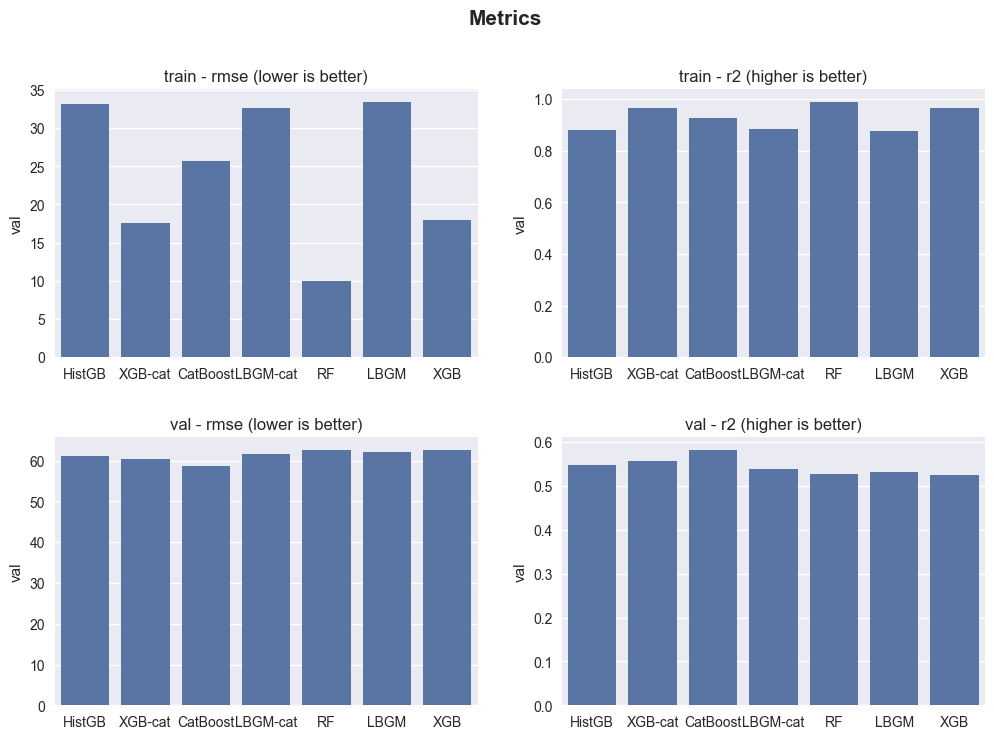

In [21]:
metrics_models = []

def calc_metrics(split: pl.DataFrame, model: dict, verbose: bool = False) -> tuple:
    X = split.select(cols_X).to_pandas()
    tgt = split.get_column(col_y).to_pandas()

    if model['is_cat'] is True:
        for col in cols_cat:
            X[col] = X[col].astype('category')

    pcs_pred = np.clip(model['model'].predict(X), a_min=0, a_max=None)
    # split = (
    #     split
    #     .groupby(['date', 'restaurant', 'meal_id', 'meal_type'])
    #     .agg({'pcs': 'mean', 'pcs_pred': 'mean'})
    #     .reset_index()
    # )
    
    
    rmse = root_mean_squared_error(tgt, pcs_pred).item()
    r2 = r2_score(tgt, pcs_pred)

    if verbose is True:
        print(f"rmse: {rmse:.4f}")
        print(f"r2  : {r2:.4f}")

    return rmse, r2

print("== Split: val")
for name, model in models.items():
    print(f"Start: {name}")

    rmse, r2 = calc_metrics(pos_val, model)
    metrics_models.append({'model': name, 'val': rmse, 'split': 'val', 'metric': 'rmse'})
    metrics_models.append({'model': name, 'val': r2, 'split': 'val', 'metric': 'r2'})


print("== Split: train")
for name, model in models.items():
    print(f"Start: {name}")

    rmse, r2 = calc_metrics(pos_train, model)
    metrics_models.append({'model': name, 'val': rmse, 'split': 'train', 'metric': 'rmse'})
    metrics_models.append({'model': name, 'val': r2, 'split': 'train', 'metric': 'r2'})



# Visualize
metrics = pd.DataFrame.from_records(metrics_models)

fig = plt.figure(figsize=(12, 8))
fig.suptitle("Metrics", fontsize=15, fontweight='bold')
fig.subplots_adjust(wspace=0.2, hspace=0.3)

for i, (split, metric) in enumerate(product(['train', 'val'], ['rmse', 'r2'])):
    df = metrics[(metrics['split'] == split) & (metrics['metric'] == metric)]

    ax = fig.add_subplot(2, 2, i+1)
    sns.barplot(df, x='model', y='val', ax=ax)
    description = "lower" if metric == "rmse" else "higher"
    ax.set_title(f"{split} - {metric} ({description} is better)")
    ax.set_xlabel("")


<Axes: xlabel='importance', ylabel='name'>

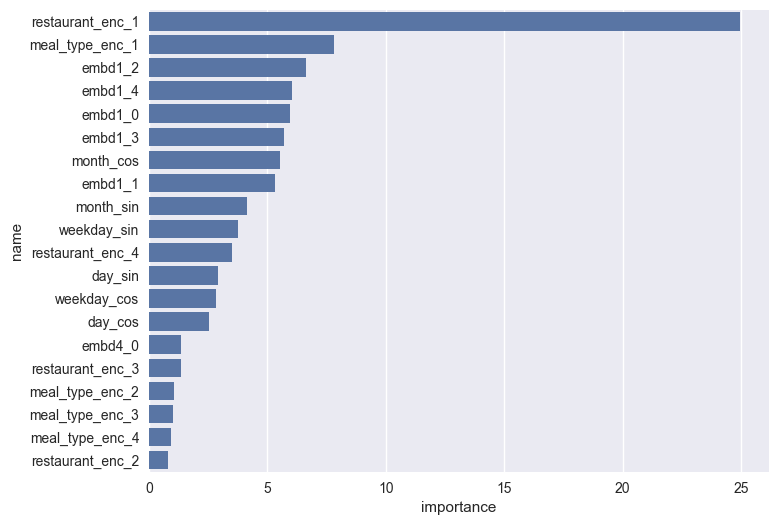

In [24]:
feat_imp = pd.DataFrame({
    'name': Xtrain.columns,
    'importance': models['CatBoost']['model'].feature_importances_
})

feat_imp.sort_values(by='importance', ascending=False, inplace=True)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
sns.barplot(feat_imp[:20], y='name', x='importance', ax=ax)

## Get `K` highest sale meals per restaurant - meal_type

In [ ]:
# K = 5
# CUTOFF_DATE = "2024-10-01"

# pos_train = pos.filter(pl.col('date') < pl.lit(CUTOFF_DATE).str.to_datetime())

In [12]:
# meals_topK = (
#     pos_train
#     .group_by('restaurant', 'meal_type', 'meal_id')
#     .agg(pl.col('pcs').sum())
#     .with_columns(
#         pl.col('pcs').rank(method='dense', descending=True).over('restaurant', 'meal_type').alias('rank')
#     )
#     .filter(pl.col('rank') <= K)
#     .drop('rank', 'pcs')
# )

# meals_topK.head()

restaurant,meal_type,meal_id
str,str,i64
"""che""","""fish""",9500055
"""exa""","""chicken""",1298
"""che""","""meat""",6945
"""phy""","""fish""",1451
"""che""","""vegetarian""",6658


In [ ]:
# meals_type = dim_meals.select('meal_id', pl.col('meal_type'))
# meal_ids_valid = meals_topK.get_column('meal_id').unique()

In [ ]:
# cosine_sim.head()

meal_id_x,meal_id_y,cosine_sim,__index_level_0__
i64,i64,f64,i64
34,37,0.040771,1
34,710,0.072106,2
34,713,0.031979,3
34,724,0.063252,4
34,725,0.026991,5


In [ ]:
# meals_similar = (
#     cosine_sim

#     # Only consider meals appearing in POS data
#     .filter(pl.col('meal_id_y').is_in(meal_ids_valid))

#     .join(meals_type, left_on='meal_id_x', right_on='meal_id', how='left')
#     .rename({'meal_type': 'meal_type_x'})
#     .join(meals_type, left_on='meal_id_y', right_on='meal_id', how='left')
#     .filter(pl.col('meal_type_x') == pl.col('meal_type'))

#     .with_columns(
#         pl.col('cosine_sim').rank('dense', descending=True).over('meal_id_x').alias('rank')
#     )
#     .filter(pl.col("rank") <= K)
#     .select('meal_id_x', 'meal_id_y', 'cosine_sim')
# )


# # Add entries for each meal with itself
# ids = meals_similar.select(pl.col('meal_id_x').unique()).get_column('meal_id_x')
# tmp = pl.DataFrame({
#     'meal_id_x': ids,
#     'meal_id_y': ids,
#     'cosine_sim': 1.0
# })
# meals_similar_all = pl.concat([meals_similar, tmp])

